# Task 2 - Detection

## Import and setup

In [1]:
import os

import cv2
from IPython.display import display
import numpy as np
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import open3d as o3d
from PIL import Image
from scipy.spatial.transform import Rotation
from sympy import Matrix
from easydict import EasyDict as edict
from typing import Tuple

import tools.dataset_tools as dataset_tools
from tools.frame_pb2 import Frame
import tools.plot_tools as plot_tools
import torch
from tqdm.notebook import tqdm

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Process raw LiDAR point cloud data

In [2]:
frame = dataset_tools.read_frame("dataset/data_2/frame_0.pb")

# print number of lidars
print(f"Number of lidars: {len(frame.lidars)}")
lidar = frame.lidars[0]

# Extract pointcloud
pcl = dataset_tools.decode_lidar(lidar)
print(f"Pointcloud shape: {pcl.shape}")

Number of lidars: 1
Pointcloud shape: (196608, 4)


## Convert to Bird's Eye View representation

In [3]:
config = edict()
config.lims = edict()
config.lims.x = [0, 50]
config.lims.y = [-25, 25]
# config.lims.z = [-2.73, 1.27]
config.lims.z = [-1, 3]
config.lims.intensity = [0, 1]
config.bev_height = 608
config.bev_width = 608

In [4]:
def pcl_to_bev(pcl: np.ndarray, config: edict) -> np.ndarray:
    """SFA3D-style BEV map creation while maintaining compatibility with your config structure
    
    Args:
        pcl: pointcloud as numpy array [n_points, m_channels]
        configs: configuration parameters containing:
            lims: dictionary with detection limits
                x: [min_x, max_x] x-axis limits in meters
                y: [min_y, max_y] y-axis limits in meters 
                z: [min_z, max_z] z-axis limits in meters
                intensity: [min_intensity, max_intensity] intensity value limits
            bev_height: height of output BEV map in pixels
            bev_width: width of output BEV map in pixels
    Returns:
        RGB_Map: BEV map as [3, height, width] array
    """
    # Create copy to avoid modifying original
    points = np.copy(pcl)
    
    # Filter points within detection range
    mask = np.where((points[:, 0] >= config.lims.x[0]) & (points[:, 0] <= config.lims.x[1]) &
                    (points[:, 1] >= config.lims.y[0]) & (points[:, 1] <= config.lims.y[1]) &
                    (points[:, 2] >= config.lims.z[0]) & (points[:, 2] <= config.lims.z[1]))
    points = points[mask]
    
    # Adjust height relative to ground (as in your implementation)
    points[:, 2] = points[:, 2] - config.lims.z[0]
    
    height = config.bev_height + 1
    width = config.bev_width + 1
    
    # Calculate discretization (similar to your bev_x_discret and bev_y_discret)
    x_discretization = (config.lims.x[1] - config.lims.x[0]) / config.bev_height
    y_discretization = (config.lims.y[1] - config.lims.y[0]) / config.bev_width
    
    # Discretize Feature Map (SFA3D style)
    points[:, 0] = np.int_(np.floor(points[:, 0] / x_discretization))  # Forward direction
    points[:, 1] = np.int_(np.floor(points[:, 1] / y_discretization) + width / 2)

    
    # Sort points (SFA3D style)
    sorted_indices = np.lexsort((-points[:, 2], points[:, 1], points[:, 0]))
    points = points[sorted_indices]
    _, unique_indices, unique_counts = np.unique(points[:, 0:2], axis=0, return_index=True, return_counts=True)
    points_top = points[unique_indices]
    
    # Initialize maps
    heightMap = np.zeros((height, width))
    intensityMap = np.zeros((height, width))
    densityMap = np.zeros((height, width))
    
    # Fill maps (SFA3D style)
    max_height = float(np.abs(config.lims.z[1] - config.lims.z[0]))
    heightMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = points_top[:, 2] / max_height
    
    # Clip intensity values and normalize
    clipped_intensities = np.clip(points_top[:, 3], config.lims.intensity[0], config.lims.intensity[1])
    intensityMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = clipped_intensities / (config.lims.intensity[1])
    
    # Density map using log normalization as in SFA3D
    densityMap[np.int_(points_top[:, 0]), np.int_(points_top[:, 1])] = np.minimum(1.0, np.log(unique_counts + 1) / np.log(64))

    # Create RGB Map (same channel ordering as SFA3D)
    bev = np.zeros((3, height - 1, width - 1))
    bev[2, :, :] = densityMap[:config.bev_height, :config.bev_width]  # r_map
    bev[1, :, :] = heightMap[:config.bev_height, :config.bev_width]   # g_map
    bev[0, :, :] = intensityMap[:config.bev_height, :config.bev_width]# b_map
    
    return bev

In [5]:
def _draw_box(config, ax, pos, scale, rotation, color, linestyle='-', label=None):
        x, y = pos[0], pos[1]  # Forward, left coordinates
        l, w = scale[0], scale[1]  # Length, width
        
        # Create rectangle points (in world coordinates)
        corners = np.array([
            [-l/2, -w/2],
            [l/2, -w/2],
            [l/2, w/2],
            [-l/2, w/2]
        ])
        
        # Rotate corners
        rot_matrix = np.array([
            [np.cos(rotation[2]), -np.sin(rotation[2])],
            [np.sin(rotation[2]), np.cos(rotation[2])]
        ])
        rotated_corners = corners @ rot_matrix.T
        
        # Convert each corner to pixel coordinates
        pixel_corners = []
        for dx, dy in rotated_corners:
            px, py = _world_to_pixel(x + dx, y + dy, config)
            pixel_corners.append([px, py])
        
        # Draw the box
        pixel_corners = np.array(pixel_corners)
        pixel_corners = np.vstack([pixel_corners, pixel_corners[0]])  # Close the rectangle
        ax.plot(pixel_corners[:, 1], pixel_corners[:, 0],  # Note: x and y are swapped for imshow
                color=color, linestyle=linestyle, label=label)

# Helper function to convert real-world coordinates to pixel coordinates
def _world_to_pixel(x, y, config):
    """Convert world coordinates to pixel coordinates based on config limits"""
    x_discretization = (config.lims.x[1] - config.lims.x[0]) / config.bev_height
    y_discretization = (config.lims.y[1] - config.lims.y[0]) / config.bev_width
    
    # Convert x coordinate (forward direction)
    # Match SFA3D's coordinate system - no inversion needed
    pixel_x = int(x / x_discretization)
    
    # Convert y coordinate (lateral direction)
    # Add width/2 to center the coordinate system
    pixel_y = int(y / y_discretization + config.bev_width / 2)
    
    return pixel_x, pixel_y

def visualize_bev(bev: np.ndarray, config: edict = None, predictions: np.ndarray = None, ground_truth: np.ndarray = None):
    """
    Visualize Bird's Eye View (BEV) data both as a combined map and individual channels
    
    Args:
        bev: numpy array of shape (channels, height, width)
        config: configuration parameters containing:
            lims: dictionary with detection limits
                x: [min_x, max_x] x-axis limits in meters
                y: [min_y, max_y] y-axis limits in meters 
                z: [min_z, max_z] z-axis limits in meters
                intensity: [min_intensity, max_intensity] intensity value limits
        predictions: list of prediction dictionaries (optional)
        ground_truth: list of ground truth dictionaries (optional)
    """

    # if predictions or ground_truth are provided, then config is required
    if predictions is not None or ground_truth is not None:
        if config is None:
            raise ValueError("config is required when predictions or ground_truth are provided")
    

    # Create a figure with a grid layout
    plt.figure(figsize=(12, 15), constrained_layout=True)
    
    # Create grid spec to control subplot sizes
    gs = plt.GridSpec(2, 3, height_ratios=[2, 1], width_ratios=[1, 1, 1], hspace=0.1, wspace=0.1)
    
    # Plot combined BEV map spanning full width
    ax1 = plt.subplot(gs[0, :])
    bev_map_display = np.transpose(bev, (1, 2, 0))
    im1 = ax1.imshow(bev_map_display, origin='lower')
    plt.colorbar(im1, ax=ax1)
    ax1.set_title("Combined Bird's Eye View Map")

    # Draw ground truth boxes
    if ground_truth:
        for gt in ground_truth:
            _draw_box(
                config,
                ax1,
                gt['pos'], 
                gt['scale'], 
                gt['rot'],
                color='r',
                linestyle='-',
                label='Ground Truth' if gt == ground_truth[0] else None
            )
    
    # Draw prediction boxes
    if predictions:
        for pred in predictions:
            _draw_box(
                config,
                ax1,
                pred['pos'], 
                pred['scale'], 
                pred['rot'],
                color='r',
                linestyle='--',
                label='Prediction' if pred == predictions[0] else None
            )
    
    plt.title("Bird's Eye View with Detections")
    plt.xlabel("Y (lateral)")
    plt.ylabel("X (forward)")
    
    if predictions or ground_truth:
        plt.legend()
    
    # Plot individual channels in bottom row
    titles = ['Density', 'Height', 'Intensity']
    for i, title in enumerate(titles):
        ax = plt.subplot(gs[1, i])
        im = ax.imshow(bev[i], origin='lower')
        plt.colorbar(im, ax=ax)
        ax.set_title(title)
    
    plt.show()



BEV shape: (3, 608, 608)


/home/twashuettl/miniconda3/envs/auto_vehicles/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


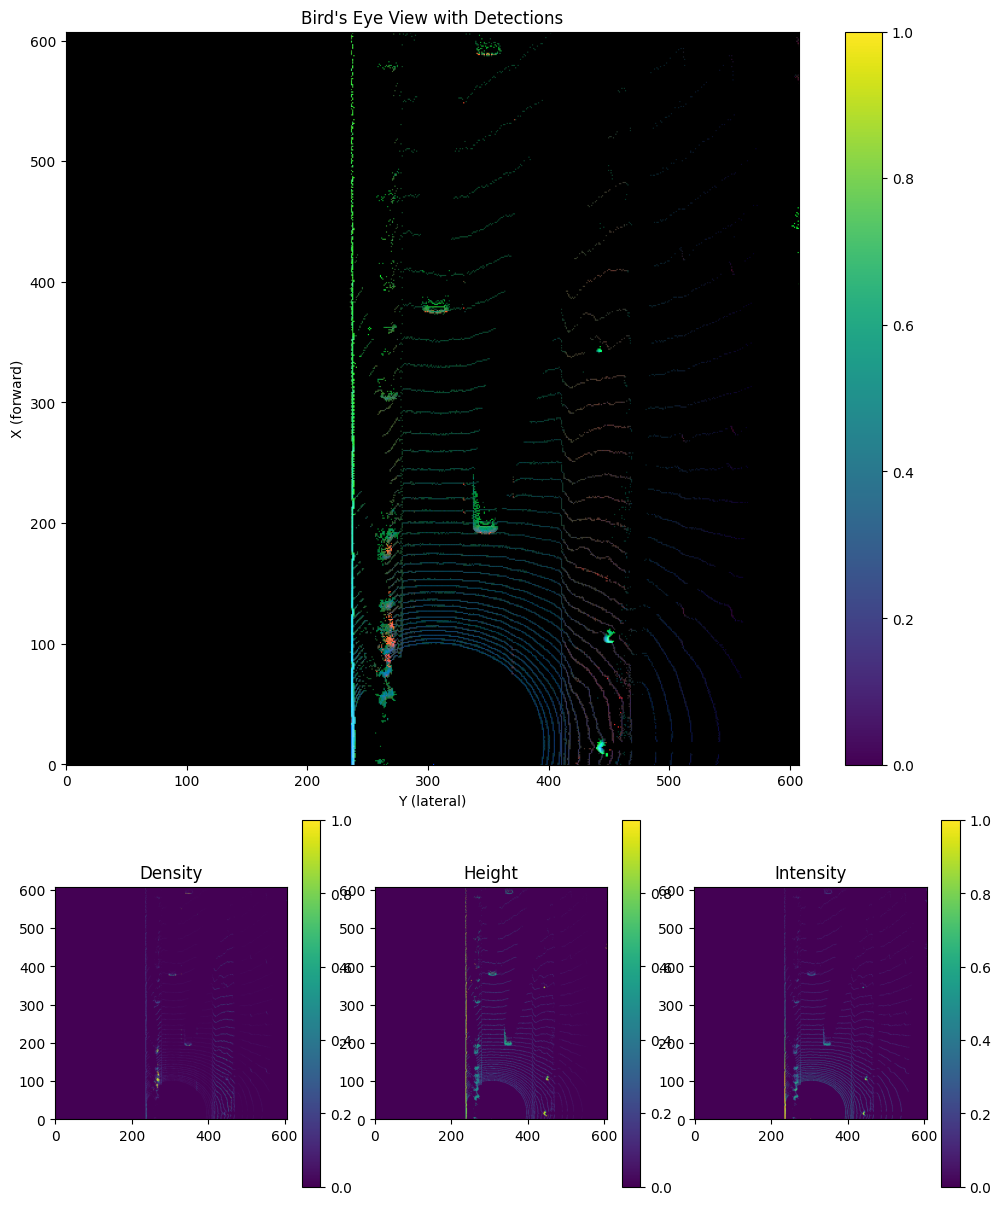

In [6]:
bev = pcl_to_bev(pcl, config)
print(f"BEV shape: {bev.shape}")

# Visualize BEV channels
visualize_bev(bev)

## Create Dataset

In [7]:
class LidarDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir: str):
        """
        Initialize the dataset
        Args:
            data_dir: path to dataset directory containing frame_*.pb files
            config: configuration dictionary with BEV parameters
        """
        self.data_dir = data_dir
        
        # Get list of all frame files
        self.frame_files = []
        for file in sorted(os.listdir(data_dir)):
            if file.startswith('frame_') and file.endswith('.pb'):
                self.frame_files.append(os.path.join(data_dir, file))
                
        print(f"Found {len(self.frame_files)} frames")
        
    def __len__(self):
        return len(self.frame_files)
    
    def __getitem__(self, idx):
        """
        Get a single frame data
        Args:
            idx: frame index
        Returns:
            pointcloud: (N, 4) array of points (x,y,z,intensity)
        """
        # Read frame
        frame = dataset_tools.read_frame(self.frame_files[idx])
        
        # Get first lidar's pointcloud
        lidar = frame.lidars[0]
        pointcloud = dataset_tools.decode_lidar(lidar)
        detections = lidar.detections
        bev = pcl_to_bev(pointcloud, config)
        
        # Convert numpy array to pytorch tensor
        bev = torch.from_numpy(bev).float()
        
        return bev, detections

# Create dataset
dataset = LidarDataset("dataset/data_2")

# Test loading first frame
bev, detections = dataset[0]
print(f"Loaded pointcloud shape: {bev.shape}")
print(f"Loaded {len(detections)} number of detections")
print(f"Detection 0: {detections[0]}")


Found 199 frames
Loaded pointcloud shape: torch.Size([3, 608, 608])
Loaded 6 number of detections
Detection 0: id: "8EFRSwEXBf9P-SzIDRzx0A"
pos: -20.02004
pos: 7.2557716
pos: 0.50248885
rot: 0.0
rot: 0.0
rot: -0.009081202
scale: 4.7602353
scale: 1.9828961
scale: 1.68



## Feed into deep learning model to detect vehicles

In [8]:
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


### Define Model

In [9]:
from SFA3D.sfa.models.model_utils import create_model
from SFA3D.sfa.utils.evaluation_utils import decode, post_processing, convert_det_to_real_values
from SFA3D.sfa.utils.torch_utils import _sigmoid

model_config = edict({
    "saved_fn": "fpn_resnet_18",
    "arch": "fpn_resnet_18",
    "pretrained_path": "./SFA3D/checkpoints/fpn_resnet_18/fpn_resnet_18_epoch_300.pth",
    "K": 50,
    "no_cuda": False,
    "gpu_idx": 0,
    "num_samples": None,
    "num_workers": 1,
    "batch_size": 1,
    "peak_thresh": 0.2,
    "save_test_output": False,
    "output_format": "image",
    "output_video_fn": "out_fpn_resnet_18",
    "output_width": 608,
})
model_config.pin_memory = True
model_config.distributed = False  # For testing on 1 GPU only

model_config.input_size = (608, 608)
model_config.hm_size = (152, 152)
model_config.down_ratio = 4
model_config.max_objects = 50

model_config.imagenet_pretrained = False
model_config.head_conv = 64
model_config.num_classes = 3
model_config.num_center_offset = 2
model_config.num_z = 1
model_config.num_dim = 3
model_config.num_direction = 2  # sin, cos

model_config.heads = {
    'hm_cen': model_config.num_classes,
    'cen_offset': model_config.num_center_offset,
    'direction': model_config.num_direction,
    'z_coor': model_config.num_z,
    'dim': model_config.num_dim
}
model_config.num_input_features = 4

model = create_model(model_config)
model.load_state_dict(torch.load(model_config.pretrained_path, map_location='cuda'))
model = model.to("cuda:0")
model.eval()


using ResNet architecture with feature pyramid


PoseResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True

In [10]:
bev, detections = dataset[0]

# Add batch dimension
bev = bev.unsqueeze(0)  # Shape: [1, 3, 608, 608]
bev = bev.to(device)
with torch.no_grad():
    outputs = model(bev)
outputs['hm_cen'] = _sigmoid(outputs['hm_cen'])
outputs['cen_offset'] = _sigmoid(outputs['cen_offset'])

# print dimensions of outputs
print(f"Outputs: {len(outputs)}")
print(f"hm_cen: {outputs['hm_cen'].size()}") # [1, 3, 152, 152] -> 3 classes
print(f"cen_offset: {outputs['cen_offset'].size()}") # [1, 2, 152, 152] -> 2 offset values
print(f"direction: {outputs['direction'].size()}") # [1, 2, 152, 152] -> 2 direction values
print(f"z_coor: {outputs['z_coor'].size()}") # [1, 1, 152, 152] -> 1 z coordinate
print(f"dim: {outputs['dim'].size()}") # [1, 3, 152, 152] -> 3 dimensions

predicted_detections = decode(outputs['hm_cen'], outputs['cen_offset'], outputs['direction'], outputs['z_coor'], outputs['dim'], K=model_config.K)
predicted_detections = predicted_detections.cpu().numpy().astype(np.float32)
predicted_detections = post_processing(predicted_detections, model_config.num_classes, model_config.down_ratio, model_config.peak_thresh)
# [cls_id, x, y, z, _h, w, l, _yaw]
predicted_detections = convert_det_to_real_values(predicted_detections[0])
print(f"Outputs: {len(outputs)}")
# print(f"Predicted detections: {predicted_detections.size}")

# predicted_detections_thresholded = predicted_detections[predicted_detections[:,:, 0] > 0.1]
# print(f"Predicted detections above threshold: {predicted_detections_thresholded.size()}")


Outputs: 5
hm_cen: torch.Size([1, 3, 152, 152])
cen_offset: torch.Size([1, 2, 152, 152])
direction: torch.Size([1, 2, 152, 152])
z_coor: torch.Size([1, 1, 152, 152])
dim: torch.Size([1, 3, 152, 152])
Outputs: 5


In [38]:
predicted_detections

array([[ 9.63762701e-01,  1.00000000e+00,  1.78608456e+01,
         3.56495285e+00, -1.68518019e+00,  1.67910528e+00,
         1.71001577e+00,  3.93173552e+00, -2.72517446e-02],
       [ 9.49798405e-01,  1.00000000e+00,  3.28237076e+01,
         1.50030136e-01, -1.57455397e+00,  1.74225652e+00,
         1.71170759e+00,  3.93619752e+00, -3.09778266e-02]])

## Evaluate detection performance

In [11]:
import torch


def convert_ground_truth_to_dict(detections):
    """
    Convert protobuf LidarDetection messages to dictionary format
    
    Args:
        detections: List of LidarDetection protobuf messages
    
    Returns:
        List of dictionaries with detection information
    """
    formatted_detections = []
    
    for det in detections:
        detection = {
            'id': det.id,
            'type': det.type,
            'pos': list(det.pos),
            'rot': list(det.rot),
            'scale': list(det.scale)
        }
        formatted_detections.append(detection)
    
    return formatted_detections

def convert_predictions_to_lidar_format(predictions, confidence_threshold=0.3):
    formatted_detections = []
    
    for pred in predictions:
        cls_id, x, y, z, _h, w, l, _yaw = pred
            
        print(formatted_detections)
        detection = {
            'id': f'pred_{len(formatted_detections)}',
            'type': cls_id,  # Class ID
            'pos': [x, y, z],  # Invert x to match visualization coordinate system
            'rot': [0.0, 0.0, _yaw],
            'scale': [l, w],  # dimensions
            'confidence': 1
        }
        
        formatted_detections.append(detection)
    
    return formatted_detections

[]
[{'id': 'pred_0', 'type': np.float64(1.0), 'pos': [np.float64(17.8608455657959), np.float64(3.564952850341797), np.float64(-1.6851801872253418)], 'rot': [0.0, 0.0, np.float64(-0.027251744642853737)], 'scale': [np.float64(3.9317355155944824), np.float64(1.7100157737731934)], 'confidence': 1}]


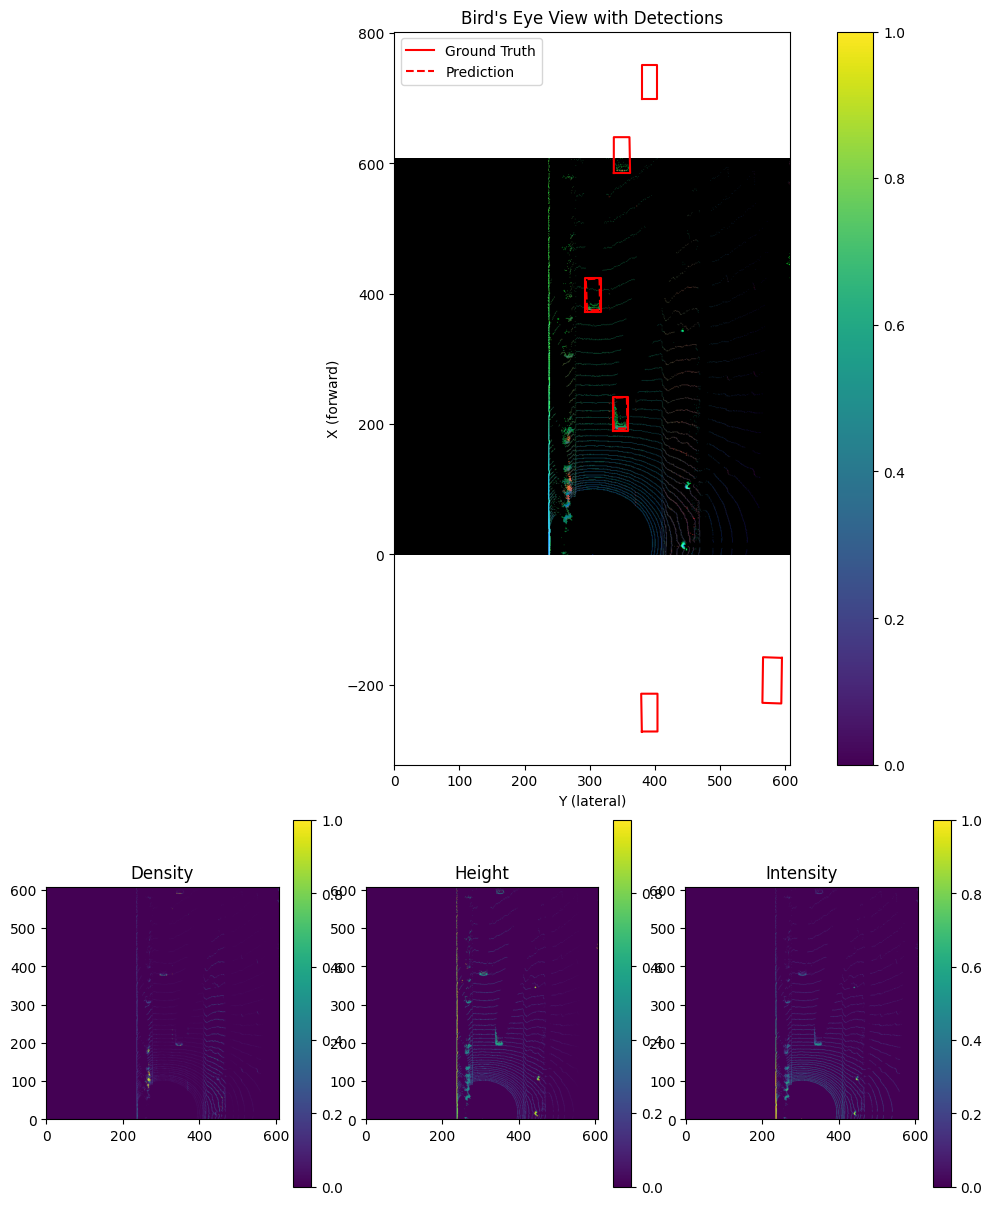

In [12]:
# from tools.lidar_tools import convert_predictions_to_lidar_format, convert_ground_truth_to_dict

pred_detections = convert_predictions_to_lidar_format(predicted_detections)
gt_detections = convert_ground_truth_to_dict(detections)

# Visualize
visualize_bev(
    bev.cpu().numpy().squeeze(0),
    predictions=pred_detections,
    ground_truth=gt_detections,
    config=config  # Pass your config
)